In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["GRB_LICENSE_FILE"] = "/usr0/home/naveenr/gurobi.lic"
os.environ['MKL_THREADING_LAYER'] = "GNU"

In [9]:
from concept_abstraction.training import *
from concept_abstraction.selection import *
from concept_abstraction.concept_bank import *
from concept_abstraction.env_utils import *
from concept_abstraction.environments import *
from concept_abstraction.utils import *
from concept_abstraction.environments import ConceptEnv
import sys 
import argparse
import secrets
import numpy as np 
import random 
import os
from stable_baselines3 import PPO
import pickle
import resource

In [10]:
torch.cuda.set_per_process_memory_fraction(0.5)
torch.set_num_threads(1)
resource.setrlimit(resource.RLIMIT_AS, (30 * 1024 * 1024 * 1024, -1))


In [11]:
is_jupyter = 'ipykernel' in sys.modules
is_main = __name__ == "__main__"

In [81]:
if is_main:
    if is_jupyter: 
        # Basics 
        seed        = 42
        environment_string = "pong"
        gold_timesteps = 4_000_000
        training_timesteps = 1
        num_concepts_selected = 1
        selection_function = "q_value"
        # Experiment #1 & #2
        run_basic = True
        run_iterative = False 
        run_two_stage = False 
        run_imperfect=False
        run_intervention=False
        # Experiment #3
        cbm_accuracy_by_concept = None 
        intervention_probability = 0
        intervention_accuracy_by_concept = None 
        cbm_std_by_concept = None 
        target_abstraction = 0.05
        reward_error = 0
        # Experiment #4
        concept_source = "human_selected"
        # Experiment #5
        assess_completeness=False
        # Experiment #6
        num_iterations = 2
        selections_per_round = 1
        initial_concepts = 0
        out_folder = "llm"
    else:
        parser = argparse.ArgumentParser()
        parser.add_argument('--seed', help='Random Seed', type=int, default=42)
        parser.add_argument('--environment_string', help='Which environment to create', type=str, default="tree")
        parser.add_argument('--training_timesteps', help='Number of training timesteps', type=int, default=10000)
        parser.add_argument('--gold_timesteps', help='Number of training timesteps without concepts', type=int, default=10000)
        parser.add_argument('--num_concepts_selected', help='Number of concepts selected by greedy or random',type=int, default=0)
        parser.add_argument('--selection_function', help='When selecting, use q_value, policy, or transition?', type=str, default="policy")
        parser.add_argument('--cbm_accuracy_by_concept', help="What is the accuracy of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--intervention_accuracy_by_concept', help="What is the accuracy of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--cbm_std_by_concept', help="What is the error of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--run_two_stage', help='Run the two stage?', action='store_true')
        parser.add_argument('--run_iterative', help='Run the iterative?', action='store_true')
        parser.add_argument('--run_intervention', help='Run the intervention?', action='store_true')
        parser.add_argument('--run_basic', help='Run the basic comparisons?', action='store_true')
        parser.add_argument('--run_imperfect', help='Run the imperfect comparisons?', action='store_true')
        parser.add_argument('--intervention_probability', help='Value for the target abstraction with human performance', type=float, default=0.05)
        parser.add_argument('--target_abstraction', help='Value for the target abstraction with human performance', type=float, default=0.05)
        parser.add_argument('--reward_error', help="How much to perturb the reward by?", type=float, default=0)
        parser.add_argument('--concept_source', help='When selecting, use q_value, policy, or transition?', type=str, default="human_selected")
        parser.add_argument('--assess_completeness', help='Compare to the concept completeness algorithm?', action='store_true')
        parser.add_argument('--num_iterations', help='Number of iterations for iterative algorithms',type=int, default=0)
        parser.add_argument('--selections_per_round', help='Concepts to select per round',type=int, default=0)
        parser.add_argument('--initial_concepts', help='Number of starting/initial concepts',type=int, default=0)
        parser.add_argument('--out_folder', help='Which folder', type=str, default="exploration")

        args = parser.parse_args()

        seed = args.seed
        environment_string = args.environment_string
        training_timesteps = args.training_timesteps 
        gold_timesteps = args.gold_timesteps
        num_concepts_selected = args.num_concepts_selected
        selection_function = args.selection_function
        cbm_accuracy_by_concept = args.cbm_accuracy_by_concept
        cbm_std_by_concept = args.cbm_std_by_concept
        run_basic = args.run_basic
        run_iterative = args.run_iterative
        run_two_stage = args.run_two_stage
        run_imperfect = args.run_imperfect
        run_intervention = args.run_intervention
        intervention_probability = args.intervention_probability
        intervention_accuracy_by_concept = args.intervention_accuracy_by_concept
        target_abstraction = args.target_abstraction
        reward_error = args.reward_error
        concept_source = args.concept_source
        assess_completeness = args.assess_completeness
        num_iterations = args.num_iterations 
        selections_per_round = args.selections_per_round
        initial_concepts = args.initial_concepts
        out_folder = args.out_folder

    save_name = secrets.token_hex(4)  

In [82]:
if is_main:
        results = {}
        results['parameters'] = {'seed'      : seed,
                'environment_string'    : environment_string, 
                'training_timesteps': training_timesteps, 
                'gold_timesteps': gold_timesteps,
                'selection_function': selection_function,
                'num_concepts_selected': num_concepts_selected,
                'cbm_accuracy_by_concept': cbm_accuracy_by_concept,
                'cbm_std_by_concept': cbm_std_by_concept,
                'intervention_probability': intervention_probability,
                'intervention_accuracy_by_concept': intervention_accuracy_by_concept,
                'target_abstraction': target_abstraction,
                'reward_error': reward_error, 
                'concept_source': concept_source,
                'assess_completeness': assess_completeness,
                'num_iterations': num_iterations,
                'selections_per_round': selections_per_round, 
                'initial_concepts': initial_concepts,
                'run_basic': run_basic,
                'run_iterative': run_iterative, 
                'run_two_stage': run_two_stage, 
                'run_intervention': run_intervention,
                'run_imperfect': run_imperfect, 
        }
        print("Parameters {}".format(results['parameters']))

Parameters {'seed': 42, 'environment_string': 'pong', 'training_timesteps': 1, 'gold_timesteps': 4000000, 'selection_function': 'q_value', 'num_concepts_selected': 1, 'cbm_accuracy_by_concept': None, 'cbm_std_by_concept': None, 'intervention_probability': 0, 'intervention_accuracy_by_concept': None, 'target_abstraction': 0.05, 'reward_error': 0, 'concept_source': 'human_selected', 'assess_completeness': False, 'num_iterations': 2, 'selections_per_round': 1, 'initial_concepts': 0, 'run_basic': True, 'run_iterative': False, 'run_two_stage': False, 'run_intervention': False, 'run_imperfect': False}


In [83]:
if is_main:
    np.random.seed(seed)
    random.seed(seed)

### Basic Setup

In [84]:
if is_main:
    concept_list = get_concepts(environment_string,concept_source,seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))
    ground_truth_env, ground_truth_gym_env, additional_info = get_environment(environment_string, None, seed)   

In [18]:
model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)

if os.path.exists(model_name):
    print("Model exists!")
    groundtruth_model = PPO.load(model_name)


Model exists!


In [21]:
num_envs = ground_truth_gym_env.num_envs
episode_rewards = [0]
rewards_accum = np.zeros(num_envs)
obs, _ = ground_truth_gym_env.reset()
total_steps = 0
steps_per = np.zeros(num_envs)
all_obs = []

while total_steps < 50_000:
    actions, _ = groundtruth_model.predict(obs)
    obs, rewards, terminated, truncated, infos = ground_truth_gym_env.step(actions)
    rewards_accum += rewards
    total_steps += num_envs 
    steps_per += 1
    all_obs.append(infos)

In [56]:
z = [all_obs[i][0]['observation'] for i in range(len(all_obs))]

In [85]:
all_vals = np.array([[c(i) for c in concept_list] for i in z])

In [88]:
np.max(all_vals,axis=0),np.min(all_vals,axis=0)

(array([0.24313725, 0.11372549, 0.25490196, 1.5       , 1.5       ,
        0.24705882, 1.5       ]),
 array([-0.36862745, -0.50196078, -0.50196078, -1.5       , -1.5       ,
        -0.50196078, -1.5       ]))

In [87]:
sorted(all_vals[:,3])

[-1.5,
 -1.5,
 -1.5,
 -1.5,
 -1.5,
 -1.5,
 -1.5,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,

In [25]:
z = np.array(z)

In [26]:
z.shape

(6250, 4, 6)

In [31]:
if is_main:
    model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
    
    if os.path.exists(model_name):
        print("Model exists!")
        groundtruth_model = PPO.load(model_name)
        additional_info['subset_concepts'] = get_concepts(environment_string,"human_selected",seed)
    else:
        if "cyclic" in environment_string or "tree" in environment_string or "glucose" in environment_string:
            policy = "MlpPolicy"
        else:
            policy = "CnnPolicy"
        
        if environment_string == "mimic":
            additional_info['subset_concepts'] = get_concepts(environment_string,"human_selected",seed)
            groundtruth_model = train_ppo_model(ground_truth_env,"mimic_raw",total_timesteps=gold_timesteps,policy=policy,additional_info=additional_info)
        else:
            groundtruth_model = train_ppo_model(ground_truth_env,environment_string,total_timesteps=gold_timesteps,policy=policy)
        groundtruth_model.save(model_name)
    groundtruth_reward = evaluate_model(environment_string,ground_truth_gym_env,additional_info,groundtruth_model,seed)
    results['ground_truth'] = {'reward':groundtruth_reward}
    print("Basic:",results['ground_truth']['reward'])

Model exists!


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Basic: -4.35307152918327


### Experimental

In [175]:
policy = "MlpPolicy"
time_per_episode = 250
num_episodes = 25
train_ppo_model(ground_truth_env,environment_string,total_timesteps=time_per_episode*num_episodes,policy=policy)

approx_kl,▁▁▂▂▂▂▂▁▁▂▂▂▁▁▁▄▄▁▁▁▁▁▁▁▁▁▁▁▃▁▄▄▄▃▁███▁▃
avg_norm_reward,▂▁▃▃▁▂▂▁▂▂▂▂▁▂▁▂▃▅▃▂▄▁▂▁▂▃▂▁▂▁▇▅▅▄▃▅▄▄█▅
clip_fraction,▁▁▂▂▁▁▁▁▁▁██▁▁▁▅▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄▁▁▁▁▂▁
ema_norm_reward,▁▂▄▄▄▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇█
entropy_loss,█▇▇▇▆▆▇▇██▇▇▆▅▅▅▅▅▄▄▄▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁▁▂▁
episode_length,▂▂▁▂▂▂▂▂▂▁▁▁▁▂▂▃▂▂▂▂▂▂▂▂▁▂▃▃▂▂▆▅▃▃▄▃▅▄▄█
episode_reward,▂▂▂▃▁▂▂▂▁▂▂▃▂▂▁▃▃▃▁▂▂▂▂▃▂▃▂▁▁▃▂▂▃▂▅▆█▂▇▃
explained_variance,▁▁▁▆▆▇▇█████████████████████████▇▇▇█████
value_loss,█▇▇▇▇▄▄▄▄▂▁▂▂▅▃▂▃▂▄▃▄▄▄▃▃▄▄▃▄▄▃▃▃▄▃▄▄▄▅▅
approx_kl,1e-05
avg_norm_reward,33.29649


In [177]:
policy = "MlpPolicy"
time_per_episode = 250
num_episodes = 25
model = train_ppo_model(ground_truth_env,environment_string,total_timesteps=time_per_episode*num_episodes,policy=policy,seed=45)

approx_kl,▁▁▁▁▁▁▁▃▃▃▁▁▄▄▄▄▂▂▂▁▁▁▁▁▃▃▃▃▃▃▃██▂▂▄▄▄▄▄
avg_norm_reward,▃▂▂▁▂▃▂▁▂▂▂▂▁▂█▂▃▁▃▃▃▁▇▃▄▄▃▃▃▄▃▆▅▅▄▆▁▆▂▃
clip_fraction,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁██▁▁▁▁▂
ema_norm_reward,▁▂▂▂▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████
entropy_loss,█▃▃▃▃▃▃▃▃▇▇▇▇▇▇▆▆▆▆▆▅▅▅███████▆▆▆▆▆▆▆▆▁▁
episode_length,▂▂▂▂▂▁▂▁▁▂▂▁▂▂▂▄▂▃▃▁▂▃▃▁▄▂▂▄▂▂▃▂▄▄▆▄█▄▃▃
episode_reward,▂▂▁▂▁▂▁▂▃▂▁▂▁▂█▂▂▃▁▃▃▁▇▃▃▅▃▄▃▃▃▃▅▆▅▇▆▁▂▃
explained_variance,▁▁▁▁▁▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇████▇▇█
value_loss,▇▇▇▇▇▆▆▂▂▂▂██▃▃▃▆▆▄▄▂▂▂▂▂▁▁▁▁▁▆▆▆▆▆▆▆▆▆▆
approx_kl,0.00392
avg_norm_reward,27.796


In [178]:
evaluate_model(environment_string,ground_truth_gym_env,additional_info,model,seed)

29.98668037529753

In [181]:
evaluate_model(environment_string,ground_truth_gym_env,additional_info,model,seed+1)

29.31876247873952

In [186]:
def lambda_to_model(func):
    class A:
        def predict(self,obs):
            return [func(i) for i in obs], None 
    return A()

In [187]:
evaluate_model(environment_string,ground_truth_gym_env,additional_info,lambda_to_model(lambda s: 0),seed)

11.590000016987323

In [188]:
evaluate_model(environment_string,ground_truth_gym_env,additional_info,lambda_to_model(bg_control_policy),seed)

18.093466264823164

In [170]:
def test_glucose(model):
    env = gym.make("simglucose/adolescent2-custom-v0", render_mode='human')
    all_rewards, total_steps = [], []
    
    for episode in range(10):
        obs, info = env.reset()
        discount = 1
        total_reward, steps = 0, 0
        done = False
        
        while not done:
            action = model(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            obs = obs[0]
            done = terminated or truncated 
            total_reward += reward * discount**steps
            steps += 1
        
        all_rewards.append(total_reward)
        total_steps.append(steps)

    print(np.mean(all_rewards), np.mean(total_steps))
    env.close()  # 👈 explicit cleanup


In [171]:
test_glucose(lambda m: model.predict([[m]])[0][0][0])

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:130: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'float'>
  logger.warn(
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


16.685860083865727 60.0


In [172]:
test_glucose(bg_control_policy)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:130: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'float'>
  logger.warn(
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


18.701908318678328 119.1


In [173]:
test_glucose(lambda m: 30)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:130: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'float'>
  logger.warn(
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


9.500000000000005 28.0


In [174]:
test_glucose(lambda m: 0)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:130: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'float'>
  logger.warn(
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


15.299999999999994 288.0


### Basic Comparison

In [33]:
q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,total_timesteps=20_000)

Starting stable training for sparse rewards...
Loss mean 0


/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/env_utils.py:367: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  states = torch.FloatTensor(states)


Episode 25, Avg Reward: -4.43, Loss (mean/std/max): 0.27/0.04/0.35, Epsilon: 0.099
Episode 50, Avg Reward: -4.45, Loss (mean/std/max): 0.25/0.05/0.35, Epsilon: 0.098


KeyboardInterrupt: 

In [32]:
if is_main:    
    model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,seed,selection_function,concept_source)
    results['basic_comparison'] = {}
    if os.path.exists(model_name):
        q_estimates = pickle.load(open(model_name,"rb"))
    else:
        if selection_function == "q_value":
            if environment_string == "mimic":
                modified_concepts = [lambda s, concept=concept: concept(additional_info['centers'][s]) 
                            for concept in concept_list]

                q_estimates = rollout_q_estimates_td(groundtruth_model,GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])),modified_concepts,learning_rate=1e-2,mimic=True,total_timesteps=10000,final_training=0)
            elif environment_string == "glucose":
                q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,total_timesteps=20_000)
            else:
                q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list)
        elif selection_function == "policy":
            if environment_string == "mimic":
                modified_concepts = [lambda s, concept=concept: concept(additional_info['centers'][s]) 
                            for concept in concept_list]

                q_estimates = rollout_pi_estimates(groundtruth_model,GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])),modified_concepts,mimic=True)
            else:
                q_estimates = rollout_pi_estimates(groundtruth_model,ground_truth_gym_env,concept_list)
        pickle.dump(q_estimates,open(model_name,"wb"))

6.873597331439727 30.1


12.075800652988969 239.6


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:334: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


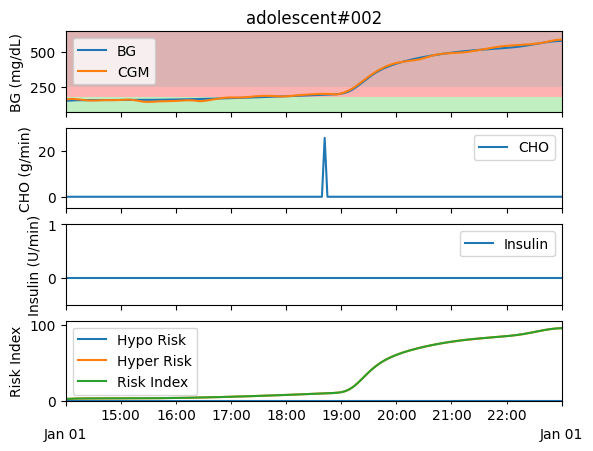

In [13]:
all_rewards=  []
total_steps = []
per_rewards = []
for episode in range(10):
    env = gymnasium.make("simglucose/adolescent2-custom-v0", render_mode="human")
    obs = env.reset()
    discount = 0.99

    total_reward = 0
    steps = 0

    done = False
    while not done:
        action =0  # replace with your agent's action
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward*discount**steps
        per_rewards.append(reward)
        steps += 1
    all_rewards.append(total_reward)
    total_steps.append(int(steps))
print(np.mean(all_rewards),np.mean(total_steps))
env.render()


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(
/tmp/ipykernel_2544639/1837526155.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  reward = float(reward)
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(
/tmp/ipykernel_2544639/1837526155.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single elem

34.146290579369506 192.8


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:334: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


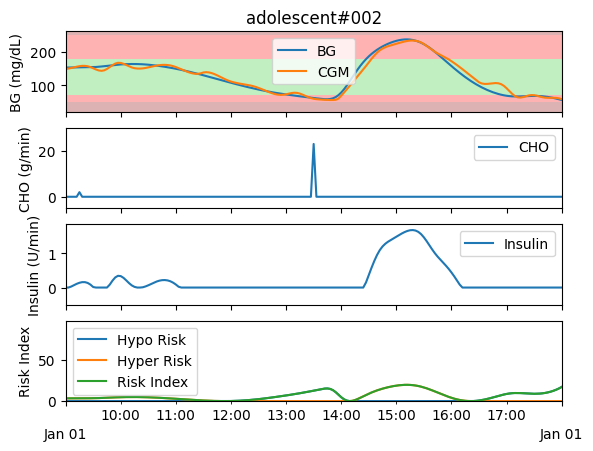

In [14]:
all_rewards=  []
total_steps = []
for episode in range(10):
    env = gymnasium.make("simglucose/adolescent2-custom-v0", render_mode="human")
    obs = env.reset()
    discount = 0.99

    total_reward = 0
    steps = 0

    done = False
    while not done:
        action = bg_control_policy(obs[0])  # replace with your agent's action
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        reward = float(reward)
        if not done:  
            total_reward += reward*discount**steps
            steps += 1
    all_rewards.append(total_reward)
    total_steps.append(int(steps))
print(np.mean(all_rewards),np.mean(total_steps))
env.render()


In [48]:
# ppo_simglucose_wandb.py

import gymnasium
import numpy as np
import wandb
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

# ------------------------------
# 1️⃣ Initialize wandb
# ------------------------------



approx_kl,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁██████████████████████
avg_norm_reward,▃▂▂█▃▅▇▂▂▇█▄▅▃▂▂▄▂▃▃▁▂▇▄▅
clip_fraction,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█████████████████████
ema_norm_reward,▁▂▂▃▄▄▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇███
entropy_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█████████████████████
episode_length,▄▁▂▆▃▆▆▂▁█▇▅▅▃▁▂▄▃▃▃▆▂▆▅▅
episode_reward,▃▂▂█▃▅▇▂▂▇█▄▅▃▂▂▄▂▃▃▁▂▇▄▅
explained_variance,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁████████████████████
value_loss,███████████████████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
approx_kl,0.00194
avg_norm_reward,2.48968


27.320203142200917 88.4


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:334: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


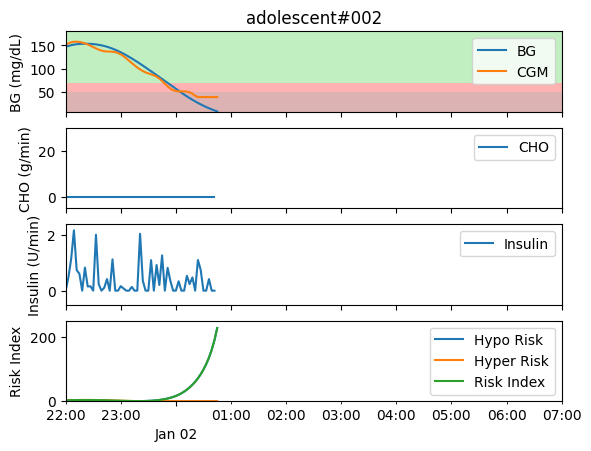

In [43]:
all_rewards=  []
total_steps = []
all_actions = []
for episode in range(10):
    env = gymnasium.make("simglucose/adolescent2-custom-v0", render_mode="human")
    obs, info = env.reset()
    discount = 0.99

    total_reward = 0
    steps = 0

    done = False
    while not done:
        action = model.predict(obs)[0][0]  # replace with your agent's action
        all_actions.append(action)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        reward = float(reward)
        if not done:  
            total_reward += reward*discount**steps
            steps += 1
    all_rewards.append(total_reward)
    total_steps.append(int(steps))
print(np.mean(all_rewards),np.mean(total_steps))
env.render()


22.155951904277703 118.0


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:334: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


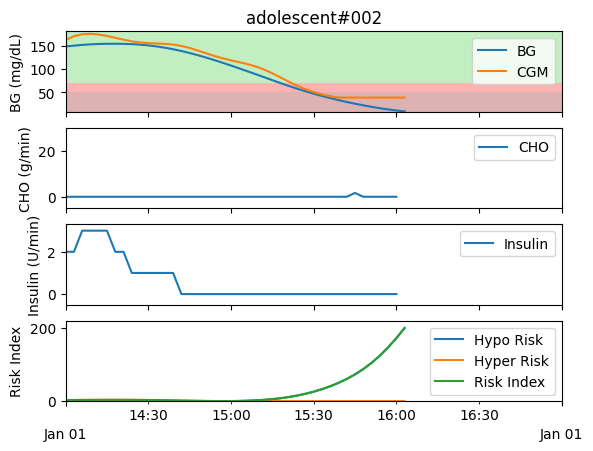

In [57]:
all_rewards=  []
total_steps = []
all_actions = []
for episode in range(10):
    env = gymnasium.make("simglucose/adolescent2-custom-v0", render_mode="human")
    obs, info = env.reset()
    discount = 0.99

    total_reward = 0
    steps = 0

    done = False
    while not done:
        action = fixed_dose_policy(obs*150)  # replace with your agent's action
        all_actions.append(action)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        reward = float(reward)
        if not done:  
            total_reward += reward*discount**steps
            steps += 1
    all_rewards.append(total_reward)
    total_steps.append(int(steps))
print(np.mean(all_rewards),np.mean(total_steps))
env.render()


In [43]:
if is_main and run_basic:
    # Train a random policy
    if environment_string == "mimic":
        model = RandomAgent(GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])))
    else:
        model = RandomAgent(ground_truth_gym_env)
    random_reward = evaluate_model(environment_string,ground_truth_gym_env,additional_info,model,seed)
    results['basic_comparison']['random'] = {'reward':random_reward}
    print("Random:",results['basic_comparison']['random']['reward'])

Random: -4.317139974766888


In [23]:
if is_main and run_basic:
    # Train a random selector
    subset_concept, random_idx = random_selection(concept_list,num_concepts_selected)
    subset_concept = [concept_list[i] for i in random_idx]
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)    
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    random_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['random_selection'] = {'reward':random_selection_reward, 'concepts': random_idx}
    print("Random Selection:",results['basic_comparison']['random_selection']['reward'])

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 8192 | AvgR_raw: -7.404 | AvgR_norm_ep: -4.086895 | EV: None | VLoss: None | KL: None | ClipF: None | GradN: None
Random Selection: -3.7970069279975216


In [72]:
if is_main and run_basic:
    # Train a greedy selector
    subset_concept, greedy_idx = greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    greedy_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['greedy'] = {'concepts': greedy_idx, 'reward':greedy_selection_reward}
    print("Greedy:",results['basic_comparison']['greedy']['reward'])


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3

Step: 8192 | AvgR_raw: -7.403 | AvgR_norm_ep: -4.373765 | EV: None | VLoss: None | KL: None | ClipF: None | GradN: None
Step: 16384 | AvgR_raw: -7.410 | AvgR_norm_ep: -4.279568 | EV: -0.22383618354797363 | VLoss: 0.7789836011826992 | KL: 0.006494460627436638 | ClipF: 0.02989501953125 | GradN: None
Step: 24576 | AvgR_raw: -7.400 | AvgR_norm_ep: -4.589157 | EV: 0.4342602491378784 | VLoss: 0.1384437395259738 | KL: 0.008804981596767902 | ClipF: 0.05390625 | GradN: None
Step: 32768 | AvgR_raw: -7.384 | AvgR_norm_ep: -4.013961 | EV: 0.7653820812702179 | VLoss: 0.07537067618686706 | KL: 0.008146359585225582 | ClipF: 0.06297607421875 | GradN: None
Step: 40960 | AvgR_raw: -7.378 | AvgR_norm_ep: -4.292973 | EV: 0.8537085503339767 | VLoss: 0.06840968360193074 | KL: 0.006765913218259811 | ClipF: 0.03675537109375 | GradN: None
Step: 49152 | AvgR_raw: -7.371 | AvgR_norm_ep: -3.953101 | EV: 0.8893469274044037 | VLoss: 0.06191394217312336 | KL: 0.005993155762553215 | ClipF: 0.0371826171875 | GradN: No

In [73]:
if is_main and run_basic:
    subset_concept, lp_idx = lp_based_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    lp_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['lp'] = {'concepts': lp_idx, 'reward': lp_selection_reward}
    print("LP Selection:",results['basic_comparison']['lp']['reward'])

Process ForkServerProcess-6:
Process ForkServerProcess-2:
Process ForkServerProcess-4:
Process ForkServerProcess-7:
Process ForkServerProcess-8:
Process ForkServerProcess-5:
Process ForkServerProcess-3:
Process ForkServerProcess-1:
Process ForkServerProcess-42:
Process ForkServerProcess-43:
Process ForkServerProcess-25:
Process ForkServerProcess-31:
Process ForkServerProcess-29:
Process ForkServerProcess-28:
Process ForkServerProcess-32:
Process ForkServerProcess-30:
Process ForkServerProcess-44:
Process ForkServerProcess-26:
Process ForkServerProcess-27:
Process ForkServerProcess-48:
Process ForkServerProcess-45:
Process ForkServerProcess-46:
Process ForkServerProcess-47:
Traceback (most recent call last):
  File "/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwarg

KeyboardInterrupt: 

In [ ]:
if is_main and run_basic:
    subset_concept, multiple_idx = multiple_lp_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    multiple_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['multiple'] = {'concepts': multiple_idx, 'reward': multiple_selection_reward}
    print("Multiple Selection:",results['basic_comparison']['multiple']['reward'])

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 8192 | AvgR_raw: -14.180 | AvgR_norm_ep: -4.619130 | EV: None | VLoss: None | KL: None | ClipF: None | GradN: None
Step: 16384 | AvgR_raw: -14.161 | AvgR_norm_ep: -4.564916 | EV: -0.02439701557159424 | VLoss: 0.6829247792717069 | KL: 0.008757958188652992 | ClipF: 0.05087890625 | GradN: None
Multiple Selection: -3.52762658876152


### Imperfect Concept Predictors

In [22]:
if is_main and run_imperfect:
    results['inaccurate_comparison'] = {}


In [23]:
if is_main and run_imperfect:
    greedy_inaccurate_reward = {}
    for modification in ["continuous","binary"]:
        if modification == "continuous" and cbm_std_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_continuous(func,0,std) for func,std in zip(concept_list,cbm_std_by_concept)]
        elif modification == "binary" and cbm_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed) for (func,acc) in zip(concept_list,cbm_accuracy_by_concept)]
        else:
            continue 
        subset_concept, greedy_idx = greedy_selection(modified_concept_predictors,num_concepts_selected,selection_function,q_estimates,concept_source)
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)

        greedy_inaccurate_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
            'concepts': greedy_idx
        }

    if greedy_inaccurate_reward != {}:
        results['inaccurate_comparison']['greedy'] = greedy_inaccurate_reward
        print(greedy_inaccurate_reward)

In [24]:
if is_main and run_imperfect:
    lp_inaccurate_reward = {}
    for modification in ["continuous","binary"]:
        if modification == "continuous" and cbm_std_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_continuous(func,0,std) for func,std in zip(concept_list,cbm_std_by_concept)]
        elif modification == "binary" and cbm_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
        else:
            continue 
        _, lp_idx = lp_based_selection(ground_truth_gym_env,modified_concept_predictors,num_concepts_selected,selection_function,q_estimates,concept_source)
        subset_concept = [modified_concept_predictors[i] for i in lp_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
        lp_inaccurate_reward[modification] = { 'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
        'concepts': lp_idx}

    if lp_inaccurate_reward != {}:
        results['inaccurate_comparison']['lp'] = lp_inaccurate_reward
        print(lp_inaccurate_reward)

In [25]:
if is_main and run_imperfect:
    multiple_lp_selection_reward = {}
    modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
    subset_concept, multiple_idx = multiple_lp_selection(ground_truth_gym_env,modified_concept_predictors,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    multiple_lp_selection_reward = {}
    multiple_lp_selection_reward['reward'] = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    multiple_lp_selection_reward['concepts'] = multiple_idx

    if multiple_lp_selection_reward != {}:
        results['inaccurate_comparison']['multiple_lp'] = multiple_lp_selection_reward
        print(multiple_lp_selection_reward)

In [26]:
if is_main and run_imperfect:
    imperfect_lp_selection_reward = {}
    for modification in ["continuous","binary"]:
        if modification == "continuous" and cbm_std_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_continuous(func,0,std) for func,std in zip(concept_list,cbm_std_by_concept)]
        elif modification == "binary" and cbm_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
        else:
            continue 
        
        if modification == "continuous":
            subset_concept, imperfect_idx = imperfect_lp_selection(ground_truth_gym_env,modified_concept_predictors,q_estimates,selection_function,target_abstraction,num_concepts_selected,cbm_accuracy_by_concept,concept_source,environment_string,additional_info,direction='min')
        else:
            subset_concept, imperfect_idx = imperfect_lp_selection(ground_truth_gym_env,modified_concept_predictors,q_estimates,selection_function,target_abstraction,num_concepts_selected,cbm_accuracy_by_concept,concept_source,environment_string,additional_info,direction='max')
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
        imperfect_lp_selection_reward[modification] = {}
        imperfect_lp_selection_reward[modification]['reward'] = evaluate_model(environment_string,eval_env,additional_info,model,seed)
        imperfect_lp_selection_reward[modification]['concepts'] = imperfect_idx

    if imperfect_lp_selection_reward != {}:
        results['inaccurate_comparison']['imperfect_lp'] = imperfect_lp_selection_reward
        print(imperfect_lp_selection_reward)

### Intervention

In [27]:
if is_main and run_intervention and intervention_accuracy_by_concept is not None:
    results['intervention_comparison'] = {}

In [31]:
if is_main and run_intervention:
    greedy_intervention_reward = {}
    for modification in ["binary"]:
        if modification == "binary" and cbm_accuracy_by_concept is not None and intervention_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,0,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        else:
            continue 
        _, greedy_idx = greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
        subset_concept = [modified_concept_predictors[i] for i in greedy_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)

        modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        subset_concept = [modified_concept_predictors[i] for i in greedy_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)

        greedy_intervention_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
            'concepts': greedy_idx
        }

    if greedy_intervention_reward != {}:
        results['intervention_comparison']['greedy'] = greedy_intervention_reward
        print(greedy_intervention_reward)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 102400 | AvgR: 111.700 | EV: -0.0549314022064209 | VLoss: 122.57731628417969 | KL: 0.004821058362722397 | ClipF: 0.008544921875 | GradN: 0.5000000094083696
Step: 204800 | AvgR: 203.160 | EV: -0.03938925266265869 | VLoss: 125.06159248352051 | KL: 0.0003838819684460759 | ClipF: 0.0 | GradN: 0.49999997220242026
Step: 307200 | AvgR: 280.520 | EV: -0.031749844551086426 | VLoss: 95.60388565063477 | KL: 0.0002391328162048012 | ClipF: 0.0 | GradN: 0.4999999326821948
Step: 409600 | AvgR: 279.620 | EV: -0.0088653564453125 | VLoss: 155.78442001342773 | KL: 0.001004572375677526 | ClipF: 0.0197265625 | GradN: 0.4999998725234221
Step: 512000 | AvgR: 280.100 | EV: -0.0007148981094360352 | VLoss: 141.37610778808593 | KL: 0.003934656269848347 | ClipF: 0.023828125 | GradN: 0.49999978430402797
Step: 614400 | AvgR: 309.040 | EV: 0.0010246038436889648 | VLoss: 110.47700996398926 | KL: 0.0008307379321195185 | ClipF: 0.0001953125 | GradN: 0.4999999110604086
Step: 716800 | AvgR: 292.810 | EV: -0.0019055

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

{'binary': {'reward': 441.24545454545455, 'concepts': [18, 5, 7, 3, 1, 20, 16, 22, 10, 15, 13, 11, 9, 8, 12]}}


In [29]:
if is_main and run_intervention:
    lp_intervention_reward = {}
    for modification in ["binary"]:
        if modification == "binary" and cbm_accuracy_by_concept is not None and intervention_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,0,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        else:
            continue 
        _, lp_idx = lp_based_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
        subset_concept = [modified_concept_predictors[i] for i in lp_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)

        modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        subset_concept = [modified_concept_predictors[i] for i in lp_idx]

        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)

        lp_intervention_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
            'concepts': lp_idx
        }

    if lp_intervention_reward != {}:
        results['intervention_comparison']['lp'] = lp_intervention_reward
        print(lp_intervention_reward)

Set parameter Username
Set parameter LicenseID to value 2709943
Academic license - for non-commercial use only - expires 2026-09-17


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 102400 | AvgR: 242.920 | EV: -0.2548503875732422 | VLoss: 156.4544876098633 | KL: 0.0004940525395795703 | ClipF: 0.0 | GradN: 0.49999994987038715


KeyboardInterrupt: 

In [ ]:
if is_main and run_intervention:
    multiple_lp_intervention_reward = {}
    modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,0,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
    subset_concept, multiple_idx = multiple_lp_selection(ground_truth_gym_env,modified_concept_predictors,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)

    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    multiple_lp_intervention_reward = {}
    modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
    subset_concept = [modified_concept_predictors[i] for i in multiple_idx]
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    multiple_lp_intervention_reward['reward'] = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    multiple_lp_intervention_reward['concepts'] = multiple_idx

    if multiple_lp_intervention_reward != {}:
        results['intervention_comparison']['multiple_lp'] = multiple_lp_intervention_reward
        print(multiple_lp_intervention_reward)

In [ ]:
if is_main and run_intervention:
    imperfect_intervention_reward = {}
    for modification in ["binary"]:
        if modification == "binary" and cbm_accuracy_by_concept is not None and intervention_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,0,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        else:
            continue 
        subset_concept, imperfect_idx = imperfect_lp_selection(ground_truth_gym_env,modified_concept_predictors,q_estimates,selection_function,target_abstraction,num_concepts_selected,cbm_accuracy_by_concept,concept_source,environment_string,additional_info,direction='max')
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
        modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        subset_concept = [modified_concept_predictors[i] for i in imperfect_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)

        imperfect_intervention_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
            'concepts': imperfect_idx
        }

    if imperfect_intervention_reward != {}:
        results['intervention_comparison']['imperfect_lp'] = imperfect_intervention_reward
        print(imperfect_intervention_reward)

### Iterative

In [20]:
if is_main and run_iterative:
    env, eval_env, additional_info = get_environment(environment_string,concept_list,seed)
    gold_model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    results['iterative'] = {}

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 26624 | AvgR: 0.024 | EV: -1.0305933952331543 | VLoss: 0.0021808540914207697 | KL: 7.24686833564192e-05 | ClipF: 0.0 | GradN: 0.09956124784979664


KeyboardInterrupt: 

In [33]:
if is_main and run_iterative:
    if cbm_accuracy_by_concept is None:
        modified_concept_predictors = concept_list 
    else:
        modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed+idx) for func,acc,idx in zip(concept_list,cbm_accuracy_by_concept,list(range(len(concept_list))))]
    rewards_iterative, concepts_iterative = iterative_selection(eval_env,gold_model,environment_string,modified_concept_predictors,num_iterations,selections_per_round,additional_info,seed,training_timesteps=training_timesteps)
    results['iterative']['iterative_selection'] = {'reward': rewards_iterative, 'concepts': concepts_iterative}
    print(rewards_iterative)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 26624 | AvgR: 0.031 | EV: -2.9340741634368896 | VLoss: 0.0037552868016064167 | KL: 9.795260848477483e-05 | ClipF: 0.0 | GradN: 0.07343096343977289
Step: 53248 | AvgR: 0.016 | EV: -4.293785572052002 | VLoss: 0.0009627111721783876 | KL: 8.177090785466135e-05 | ClipF: 0.0 | GradN: 0.10021883000974288
Step: 79872 | AvgR: 0.015 | EV: -0.055642127990722656 | VLoss: 0.0024082461604848504 | KL: 5.8065110351890326e-05 | ClipF: 0.0 | GradN: 0.06338761756980402
Step: 106496 | AvgR: 0.006 | EV: -5.718072891235352 | VLoss: 0.0002673135313671082 | KL: 0.0007329407962970436 | ClipF: 0.0 | GradN: 0.13141616160175504
Step: 133120 | AvgR: 0.030 | EV: 0.0857841968536377 | VLoss: 0.0007162279798649251 | KL: 0.0001690398494247347 | ClipF: 0.0 | GradN: 0.08319026410871454
Step: 159744 | AvgR: 0.030 | EV: -0.6757372617721558 | VLoss: 0.0001277085830224678 | KL: 0.0003160064516123384 | ClipF: 0.0 | GradN: 0.10731181098692963
Step: 186368 | AvgR: 0.034 | EV: -0.00741267204284668 | VLoss: 0.00038591801421

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 26624 | AvgR: 0.027 | EV: -3.656022548675537 | VLoss: 0.004133887472562492 | KL: 4.281985457055271e-05 | ClipF: 0.0 | GradN: 0.08753655661349974
Step: 53248 | AvgR: 0.044 | EV: -0.336590051651001 | VLoss: 0.004341385560110211 | KL: 5.003996193408966e-05 | ClipF: 0.0 | GradN: 0.08825755900616683
Step: 79872 | AvgR: 0.037 | EV: -8.794474601745605 | VLoss: 0.0012464909232221544 | KL: 3.715170896612108e-05 | ClipF: 0.0 | GradN: 0.07650207764355273
Step: 106496 | AvgR: 0.032 | EV: -0.36394453048706055 | VLoss: 0.0018414868973195553 | KL: 6.503157783299685e-05 | ClipF: 0.0 | GradN: 0.09306985667691595
Step: 133120 | AvgR: 0.017 | EV: -0.03443503379821777 | VLoss: 0.0011967774480581284 | KL: 0.00019823532784357667 | ClipF: 0.0 | GradN: 0.08875120503022317
Step: 159744 | AvgR: 0.049 | EV: -2.6846468448638916 | VLoss: 0.0005066700396127999 | KL: 6.289876182563603e-05 | ClipF: 0.0 | GradN: 0.07401174665226455
Step: 186368 | AvgR: 0.109 | EV: -0.0786210298538208 | VLoss: 0.00153220922220498

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 26624 | AvgR: 0.016 | EV: -1.3977806568145752 | VLoss: 0.005321290576830506 | KL: 2.3126136511564255e-05 | ClipF: 0.0 | GradN: 0.10249145687709897
Step: 53248 | AvgR: 0.040 | EV: -6.812435626983643 | VLoss: 0.0019025513902306557 | KL: 5.513962241820991e-05 | ClipF: 0.0 | GradN: 0.08388031430540588
Step: 79872 | AvgR: 0.066 | EV: -1.9781222343444824 | VLoss: 0.0016270928899757564 | KL: 0.00040626563713885844 | ClipF: 0.0 | GradN: 0.11370064533935101
Step: 106496 | AvgR: 0.129 | EV: -0.5537551641464233 | VLoss: 0.001734612334985286 | KL: 0.00020382183720357716 | ClipF: 0.0 | GradN: 0.0944010254233111
Step: 133120 | AvgR: 0.173 | EV: 0.20164430141448975 | VLoss: 0.008733588270843029 | KL: 0.0002435210335534066 | ClipF: 0.0 | GradN: 0.14667126240361486
Step: 159744 | AvgR: 0.259 | EV: 0.16103923320770264 | VLoss: 0.006296081701293588 | KL: 0.00011872916365973651 | ClipF: 0.0 | GradN: 0.08760201152160195
Step: 186368 | AvgR: 0.307 | EV: 0.3378608822822571 | VLoss: 0.006283058086410165

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 26624 | AvgR: 0.039 | EV: -1.6143879890441895 | VLoss: 0.006079325685277581 | KL: 1.6136211343109608e-05 | ClipF: 0.0 | GradN: 0.07566121628822604
Step: 53248 | AvgR: 0.051 | EV: -3.642019271850586 | VLoss: 0.0018266753759235144 | KL: 2.5411078240722418e-05 | ClipF: 0.0 | GradN: 0.09271951485746158
Step: 79872 | AvgR: 0.064 | EV: -1.9249505996704102 | VLoss: 0.001625938224606216 | KL: 4.436494782567024e-05 | ClipF: 0.0 | GradN: 0.09969185960022665
Step: 106496 | AvgR: 0.053 | EV: 0.15980732440948486 | VLoss: 0.003226686269044876 | KL: 3.1964940717443824e-05 | ClipF: 0.0 | GradN: 0.11121128077267356
Step: 133120 | AvgR: 0.099 | EV: 0.12325316667556763 | VLoss: 0.0018953586113639176 | KL: 0.00013513959129340947 | ClipF: 0.0 | GradN: 0.12538497204078344
Step: 159744 | AvgR: 0.211 | EV: 0.24259686470031738 | VLoss: 0.005651357816532254 | KL: 0.0002834242768585682 | ClipF: 0.0 | GradN: 0.11829722568999475
Step: 186368 | AvgR: 0.237 | EV: -0.020496606826782227 | VLoss: 0.00472081964835

In [31]:
if is_main and run_iterative:
    if cbm_accuracy_by_concept is None:
        modified_concept_predictors = concept_list 
    else:
        modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed+idx) for func,acc,idx in zip(concept_list,cbm_accuracy_by_concept,list(range(len(concept_list))))]

    num_concepts_selected = num_iterations*selections_per_round
    bayesian_reward, bayesian_idx = bayesian_iterative_selection(ground_truth_gym_env,environment_string,seed,modified_concept_predictors,num_iterations+1,num_concepts_selected,additional_info,training_timesteps=training_timesteps)

    results['iterative']['bayesian'] = {
        'reward': bayesian_reward, 
        'concepts': bayesian_idx
    }
    print(bayesian_reward)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 4096 | AvgR: 20.260 | EV: None | VLoss: None | KL: None | ClipF: None | GradN: 0.0


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 4096 | AvgR: 22.240 | EV: None | VLoss: None | KL: None | ClipF: None | GradN: 0.0


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

Step: 4096 | AvgR: 22.470 | EV: None | VLoss: None | KL: None | ClipF: None | GradN: 0.0
[22.40745732255166, 22.2, 22.39793629430238]


### Two-Stage Training

In [32]:
if is_main and run_two_stage:
    env, eval_env, additional_info = get_environment(environment_string,concept_list,seed)
    gold_model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)

In [33]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    concept_predictor, acc_list = train_concept_predictor(ground_truth_gym_env,gold_model,concept_list,list(range(len(concept_list))))
    results['two_stage'] = {}
    results['two_stage']['accuracy'] = acc_list 


In [34]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    greedy_two_stage = {}
    greedy_concepts, greedy_idx = greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)

    concept_predictor, _ = train_concept_predictor(ground_truth_gym_env,gold_model,concept_list,greedy_idx)
    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, greedy_concepts, seed,fast_predictor=concept_predictor,use_processed=True)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps)    
    greedy_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['greedy'] = {'reward': greedy_two_stage_reward, 'concepts': greedy_idx}
    print(greedy_two_stage_reward)



In [35]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    greedy_iterative_concepts, greedy_iterative_idx = greedy_iterative_selection(concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)

    concept_predictor, _ = train_concept_predictor(ground_truth_gym_env,gold_model,concept_list,greedy_iterative_idx)
    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, greedy_concepts, seed,fast_predictor=concept_predictor,use_processed=True)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps)    
    greedy_iterative_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['greedy_iterative'] = {'reward': greedy_iterative_two_stage_reward, 'concepts': greedy_iterative_idx}
    print(greedy_iterative_two_stage_reward)



In [36]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    lp_concepts, lp_idx = lp_based_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)

    concept_predictor, _ = train_concept_predictor(ground_truth_gym_env,gold_model,concept_list,lp_idx)
    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, lp_concepts, seed,fast_predictor=concept_predictor,use_processed=True)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps)    
    lp_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['lp'] = {'reward': lp_two_stage_reward, 'concepts': lp_idx}
    print(lp_two_stage_reward)



In [37]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    acc_list = results['two_stage']['accuracy']
    top_k_idx = np.argsort(acc_list)[-num_concepts_selected:]
    top_k_concepts = [concept_list[i] for i in top_k_idx]
    
    concept_predictor, _ = train_concept_predictor(ground_truth_gym_env,gold_model,concept_list,top_k_idx)
    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, top_k_concepts, seed,fast_predictor=concept_predictor,use_processed=True)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps)    
    top_k_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['top_k'] = {'reward': top_k_two_stage_reward, 'concepts': top_k_idx}
    print(top_k_two_stage_reward)



In [38]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    acc_list = results['two_stage']['accuracy']
    imperfect_concepts, imperfect_idx = imperfect_lp_selection(ground_truth_gym_env,concept_list,q_estimates,selection_function,target_abstraction,num_concepts_selected,acc_list,concept_source,environment_string,additional_info,direction='max')
    
    concept_predictor, _ = train_concept_predictor(ground_truth_gym_env,gold_model,concept_list,imperfect_idx)
    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, imperfect_concepts, seed,fast_predictor=concept_predictor,use_processed=True)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps)    
    imperfect_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['imperfect'] = {'reward': imperfect_two_stage_reward, 'concepts': imperfect_idx}
    print(imperfect_two_stage_reward)

## Ablations

### Reward Perturbation

In [37]:
if is_main and reward_error > 0:
    results['reward_error'] = {}
    perturbed_groundtruth_eval_env = RewardPerturbationWrapper(ground_truth_gym_env,reward_error)

    if selection_function == "q_value":
        if environment_string == "mimic":
            q_estimates_perturbed = rollout_q_estimates_td(groundtruth_model,GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])),concept_list,learning_rate=1e-3,mimic=True,total_timesteps=5000,final_training=0)
        else:
            q_estimates_perturbed = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list)
    elif selection_function == "policy":
        if environment_string == "mimic":
            q_estimates_perturbed = rollout_pi_estimates(groundtruth_model,GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])),concept_list,mimic=True)
        else:
            q_estimates_perturbed = rollout_pi_estimates(groundtruth_model,ground_truth_gym_env,concept_list)

    subset_concept, greedy_perturbed_idx = greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates_perturbed,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    perturbed_model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    greedy_selection_perturbed_reward = evaluate_model(environment_string,eval_env,additional_info,perturbed_model,seed)
    results['reward_error']['greedy'] = {
        'reward': greedy_selection_perturbed_reward,
        'concepts': greedy_perturbed_idx
    }
    print(greedy_selection_perturbed_reward)

In [38]:
if is_main and reward_error > 0:
    subset_concept, greedy_perturbed_iterative_idx = greedy_iterative_selection(concept_list,num_concepts_selected,selection_function,q_estimates_perturbed,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    greedy_iterative_selection_perturbed_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['reward_error']['greedy_iterative'] = {
        'reward': greedy_iterative_selection_perturbed_reward,
        'concepts': greedy_perturbed_iterative_idx
    }
    print(greedy_iterative_selection_perturbed_reward)

In [39]:
if is_main and reward_error > 0:
    subset_concept, lp_perturbed_idx = lp_based_selection(concept_list,num_concepts_selected,selection_function,q_estimates_perturbed,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    lp_selection_perturbed_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['reward_error']['lp'] = {
        'reward': lp_selection_perturbed_reward,
        'concepts': lp_perturbed_idx
    }
    print(lp_selection_perturbed_reward)

### Comparison with Concept Completeness

In [40]:
# TODO: Create a Shapley-based baseline
if is_main and assess_completeness:
    pass 


## Save Data

In [ ]:
if is_main:
    save_path = get_save_path(out_folder,save_name)

In [ ]:
if is_main:
    delete_duplicate_results(out_folder,"",results)

In [ ]:
if is_main:
    json.dump(results,open('../../results/'+save_path,'w'))

In [ ]:
if is_main:
    ground_truth_env.close()
    ground_truth_gym_env.close()
    env.close()
    eval_env.close()